# Exploratory Data Analysis (EDA)

## Objective

The goal of this notebook is to explore the IBM Telco Customer Churn dataset through statistical summaries and visualizations. We aim to identify patterns, trends, and relationships that may explain customer churn and guide feature engineeraing and predictive model development.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu

plt.style.use("ggplot")

pd.set_option('display.max_rows', None)

## Load Dataset

In [2]:
df = pd.read_csv('../data/raw/Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Target Variable

In [3]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [4]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

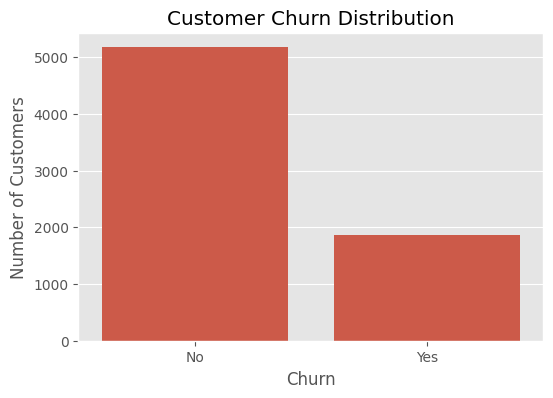

In [5]:
plt.figure(figsize=(6,4))

sns.countplot(data = df, x='Churn')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

In [6]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

### Insight

The target variable is moderately imbalanced.

About the 73.4% is not churn compared to 26.5% that churned, so model evaluation should rely on metrics such as Precision, Recall, F1-score, and ROC-AUC instead of accuracy alone.

## Numerical Features

In [7]:
num_col = [
    'tenure',
    'MonthlyCharges'
    ]

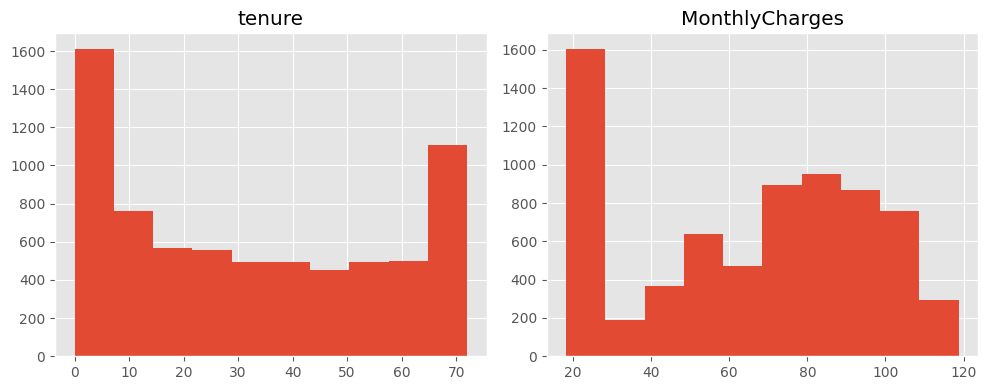

In [8]:
df[num_col].hist(figsize=(10, 4))

plt.tight_layout()
plt.show()

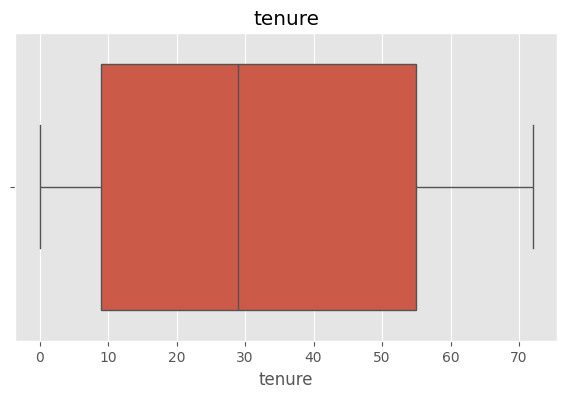

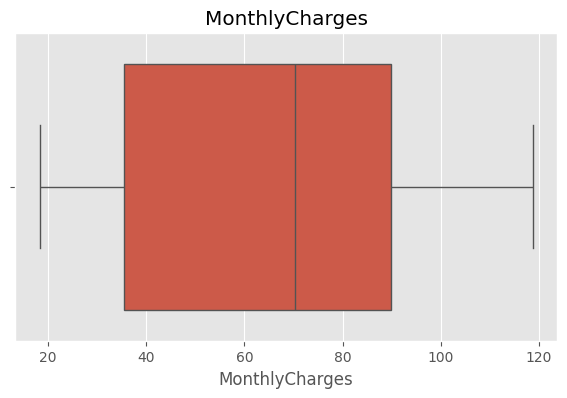

In [9]:
for col in num_col:

    plt.figure(figsize=(7, 4))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()



In [10]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    print(f"--- {column} ---")
    print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")
    print(f"Number of outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
    
    return outliers

for col in ['tenure', 'MonthlyCharges']:
    detect_outliers_iqr(df, col)
    print()

--- tenure ---
Q1: 9.00, Q3: 55.00, IQR: 46.00
Lower bound: -60.00, Upper bound: 124.00
Number of outliers: 0 (0.00%)

--- MonthlyCharges ---
Q1: 35.50, Q3: 89.85, IQR: 54.35
Lower bound: -46.02, Upper bound: 171.38
Number of outliers: 0 (0.00%)



### Insight

the tenure is right-skewed with a large concentration of new customers and another concentration of near the maximum tenure.

Based on the IQR rule **(1.5*IQR)**, no outliers were detected in either `tenure` or `MonthlyCharges`, confirming the visual inspection from the boxplot above.

Also we can see the `MonthlyCharge` feature does not follow normaly distribution, in the histogram we can see that there a pronounced peak to the left side.

We can see that both need to scaling, because the powers and units of these two variables are different, if we want to use an algorithm that is sensitive to area and distance (such as `KNN`,`SVM` or `Linear/Logistic regression` and `neural networks` ), changes in will have a greater impact on the model due to larger number.

## Categorical Features

In [11]:
cat_cols = [
    "gender",
    "Partner",
    "Dependents",
    "Contract",
    "InternetService",
    "PaymentMethod"
]

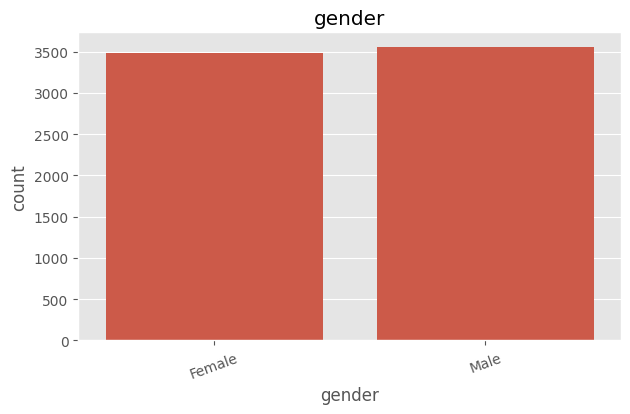

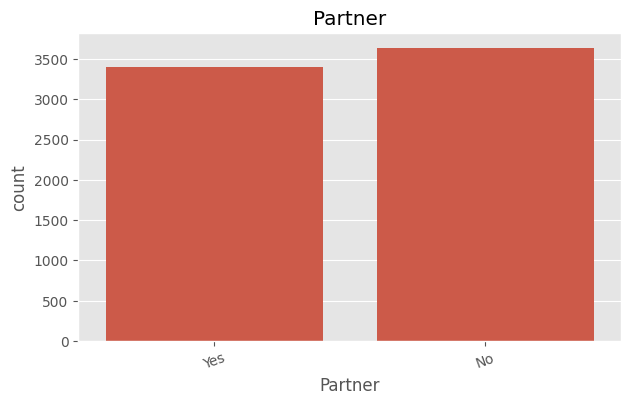

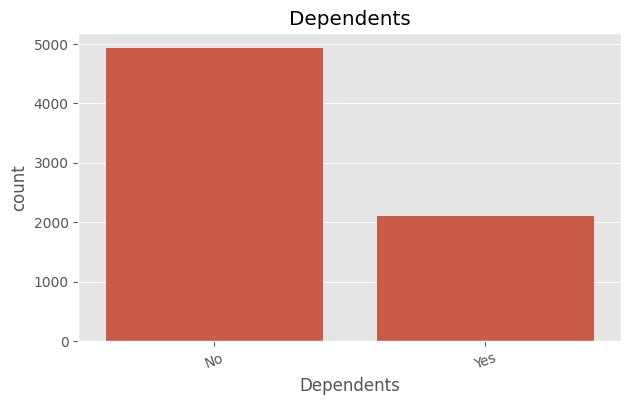

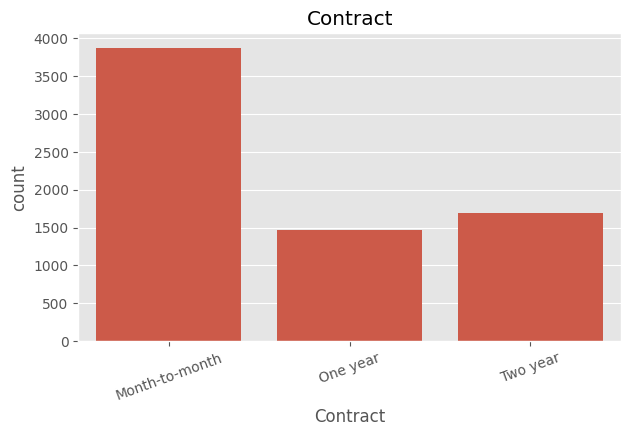

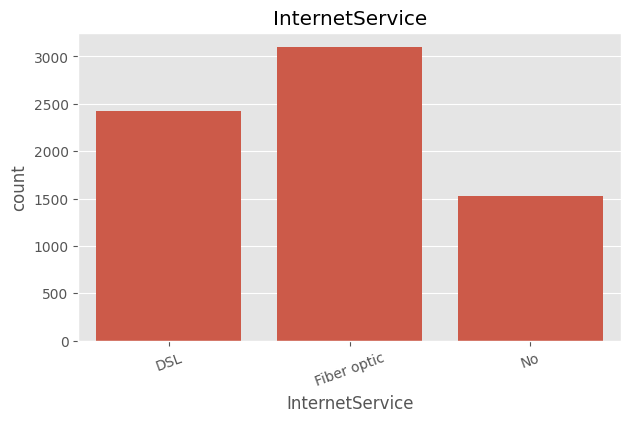

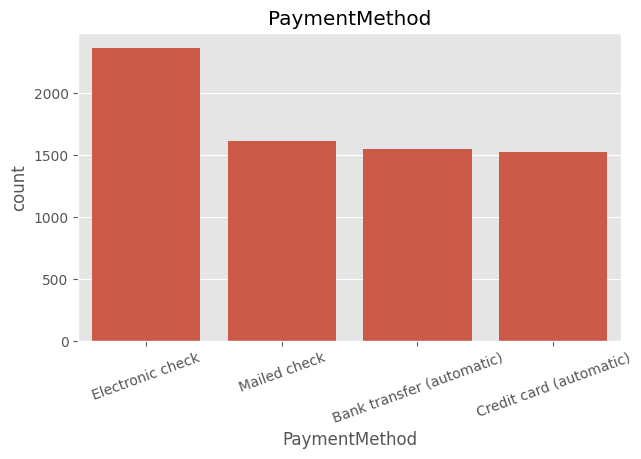

In [12]:
for col in cat_cols:

    plt.figure(figsize=(7, 4))

    sns.countplot(data=df, x=col)

    plt.xticks(rotation=20)

    plt.title(col)

    plt.show()

In [13]:
for col in cat_cols:
    print(f"--- {col} ---")
    print((df[col].value_counts(normalize=True) * 100).round(1))
    print()

--- gender ---
gender
Male      50.5
Female    49.5
Name: proportion, dtype: float64

--- Partner ---
Partner
No     51.7
Yes    48.3
Name: proportion, dtype: float64

--- Dependents ---
Dependents
No     70.0
Yes    30.0
Name: proportion, dtype: float64

--- Contract ---
Contract
Month-to-month    55.0
Two year          24.1
One year          20.9
Name: proportion, dtype: float64

--- InternetService ---
InternetService
Fiber optic    44.0
DSL            34.4
No             21.7
Name: proportion, dtype: float64

--- PaymentMethod ---
PaymentMethod
Electronic check             33.6
Mailed check                 22.9
Bank transfer (automatic)    21.9
Credit card (automatic)      21.6
Name: proportion, dtype: float64



### Business Insight

A few things stand out in the categorical mix. Gender is close to a coin flip (50.5% / 49.5%), so it's unlikely to carry much predictive weight on its own. Family structure is more interesting — 48.3% of customers have a partner but only 30% have dependents, meaning most of the customer base doesn't have someone else's needs tying them to a stable plan.

Contract type is the one worth watching closest: over 55% of customers are month-to-month, which is a lot of people with zero switching friction. Fiber optic edges out DSL as the dominant internet service (44% vs. 34.4%), and Electronic check leads payment methods at 33.6% — both of these will come back with a vengeance in the churn cross-tabs below.

## Features VS Churn

### Which customer group churn the most?

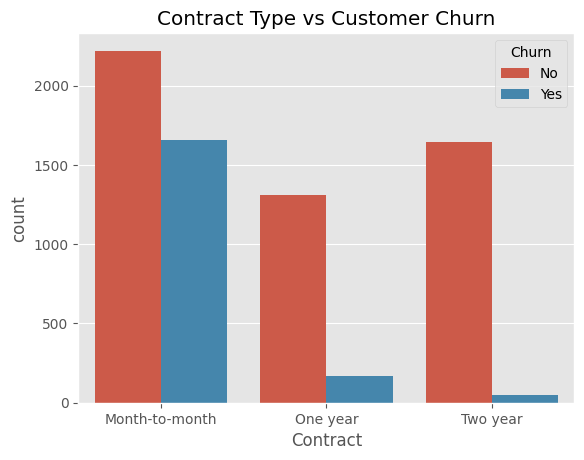

In [14]:
# The customer that churn 
sns.countplot(
    data=df,
    x='Contract',
    hue='Churn'
)
plt.title('Contract Type vs Customer Churn')
plt.show()

In [15]:
contingency_table = pd.crosstab(df['Contract'], df['Churn'])
print(contingency_table)


chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-square statistic: {chi2:.2f}")
print(f"p-value: {p_value:.10f}")
print(f"Degrees of freedom: {dof}")

if p_value < 0.05:
    print("→ The relationship is significant (H0 is rejected)")
else:
    print("→ The relationship isn't significant")

Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48

Chi-square statistic: 1184.60
p-value: 0.0000000000
Degrees of freedom: 2
→ The relationship is significant (H0 is rejected)


### Business Insight

Customers that had Month-to-month `Contract` churn more often, We need to pay more attention to customers who sign month-to-month contracts.

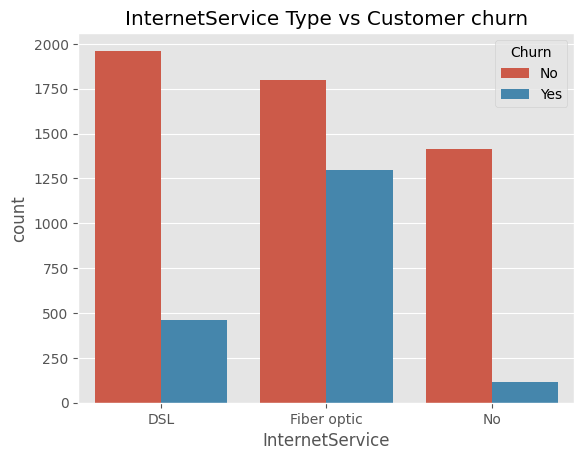

In [16]:
# countplot for internet service feature by churn
sns.countplot(
    data=df,
    x='InternetService',
    hue='Churn'
)
plt.title('InternetService Type vs Customer churn')
plt.show()

In [17]:
contingency_table = pd.crosstab(df['InternetService'], df['Churn'])
print(contingency_table)


chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-square statistic: {chi2:.2f}")
print(f"p-value: {p_value:.10f}")
print(f"Degrees of freedom: {dof}")

if p_value < 0.05:
    print("→ The relationship is significant (H0 is rejected)")
else:
    print("→ The relationship isn't significant")

Churn              No   Yes
InternetService            
DSL              1962   459
Fiber optic      1799  1297
No               1413   113

Chi-square statistic: 732.31
p-value: 0.0000000000
Degrees of freedom: 2
→ The relationship is significant (H0 is rejected)


In [18]:
def churn_rate_by_group(df, column):
    result = df.groupby(column)['Churn'].value_counts(normalize=True).unstack() * 100
    return result.round(2)

print(churn_rate_by_group(df, 'InternetService'))

Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


### Business Insight

- Customers with **Fiber optic** internet service show a very high churn rate (approx. 41.9%), compared to **DSL** users (approx. 19.0%).
- Customers with **no internet service** have the lowest churn rate (approx. 7.4%).
- This may suggests that fiber optic customers, despite paying for premium high-speed internet, are significantly more likely to churn. This could point to issues with pricing, service quality, or support.

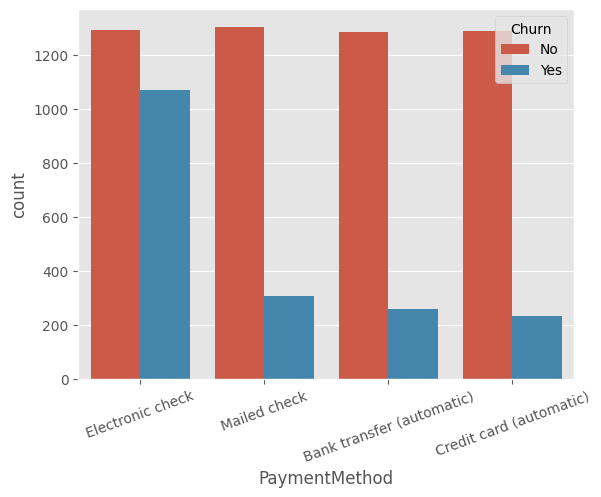

In [19]:
# countplot for payment method feature by churn
sns.countplot(
    data=df,
    x='PaymentMethod',
    hue='Churn'
)
plt.xticks(rotation=20)
plt.show()

In [20]:
contingency_table = pd.crosstab(df['PaymentMethod'], df['Churn'])
print(contingency_table)


chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-square statistic: {chi2:.2f}")
print(f"p-value: {p_value:.10f}")
print(f"Degrees of freedom: {dof}")

if p_value < 0.05:
    print("→ The relationship is significant (H0 is rejected)")
else:
    print("→ The relationship isn't significant")

Churn                        No   Yes
PaymentMethod                        
Bank transfer (automatic)  1286   258
Credit card (automatic)    1290   232
Electronic check           1294  1071
Mailed check               1304   308

Chi-square statistic: 648.14
p-value: 0.0000000000
Degrees of freedom: 3
→ The relationship is significant (H0 is rejected)


In [21]:
print(churn_rate_by_group(df, 'PaymentMethod'))

Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11


### Business Insight

- Customers paying with **Electronic check** exhibit a remarkably high churn rate (approx. 45.3%), making it the payment method most associated with churn.
- In contrast, customers utilizing automatic payment methods like **Credit card (automatic)** (approx. 15.2%) and **Bank transfer (automatic)** (approx. 16.7%) have much lower churn rates.
- Customers paying by **Mailed check** have a churn rate of approx. 19.1%.

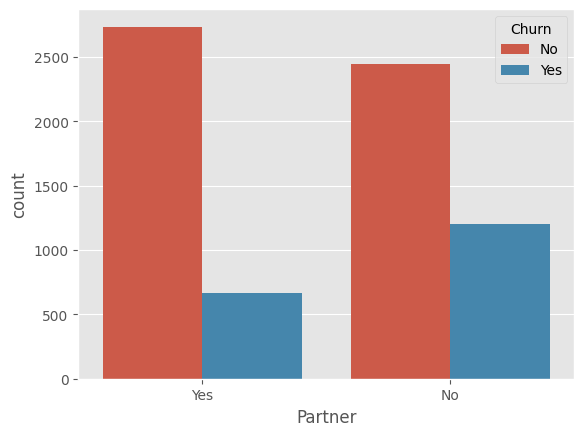

In [22]:
# countplot for partner feature by churn
sns.countplot(
    data=df,
    x='Partner',
    hue='Churn'
)
plt.show()

In [23]:
print(churn_rate_by_group(df, 'Partner'))

Churn       No    Yes
Partner              
No       67.04  32.96
Yes      80.34  19.66


### Business Insight

- Customers **without a partner** have a higher churn rate (approx. 33.0%) compared to those who **have a partner** (approx. 19.7%).
- Having a partner seems to be associated with higher customer retention.

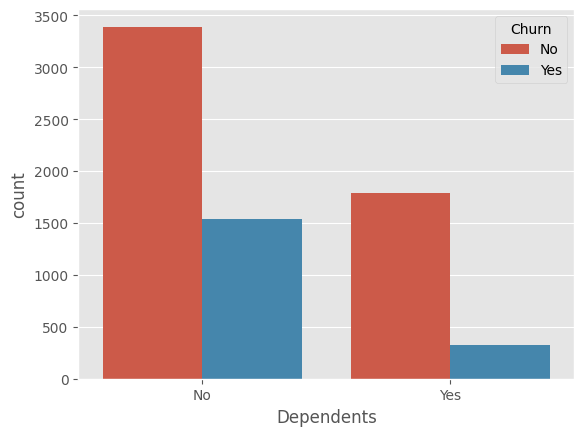

In [24]:
# countplot for dependents feature by churn
sns.countplot(
    data=df,
    x='Dependents',
    hue='Churn'
)
plt.show()

In [25]:
print(churn_rate_by_group(df, 'Dependents'))

Churn          No    Yes
Dependents              
No          68.72  31.28
Yes         84.55  15.45


### Business Insight

- Customers **without dependents** have a significantly higher churn rate (approx. 31.3%) compared to customers **with dependents** (approx. 15.5%).
- Customers with family ties (partners or dependents) are generally more stable and less prone to churn.

In [26]:
categorical_vars = ['Contract', 'InternetService', 'PaymentMethod', 'Partner', 'Dependents']

spread_summary = []
for col in categorical_vars:
    rates = df.groupby(col)['Churn'].value_counts(normalize=True).unstack()['Yes'] * 100
    spread = rates.max() - rates.min()
    spread_summary.append({'variable': col, 'max_rate': rates.max(), 'min_rate': rates.min(), 'spread': spread})

spread_df = pd.DataFrame(spread_summary).sort_values('spread', ascending=False)
print(spread_df)

          variable   max_rate   min_rate     spread
0         Contract  42.709677   2.831858  39.877819
1  InternetService  41.892765   7.404980  34.487785
2    PaymentMethod  45.285412  15.243101  30.042311
4       Dependents  31.279140  15.450237  15.828904
3          Partner  32.957979  19.664903  13.293076


## Numerical Features VS Churn

### Do customers who churn have different tenure or monthly charges?

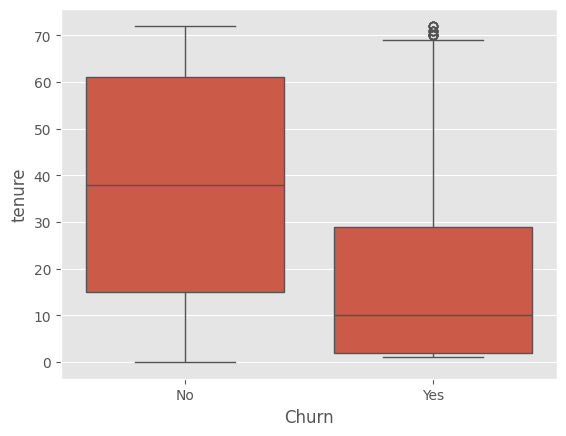

In [27]:
# boxplot for tenure feature by churn
sns.boxplot(
    data=df,
    x='Churn',
    y='tenure'
)
plt.show()

In [28]:
tenure_churn_yes = df[df['Churn'] == 'Yes']['tenure']
tenure_churn_no = df[df['Churn'] == 'No']['tenure']

stat, p_value = mannwhitneyu(tenure_churn_yes, tenure_churn_no, alternative='two-sided')

print(f'Mann-Whitney U statistic: {stat:.2f}')
print(f'p-value: {p_value:.10f}')


if p_value < 0.5 :
    print('The relationship is significant (H0 is rejected)')
else:
    print("The relationship isn't significant.")

print(f"\nMedian tenure - Churned: {tenure_churn_yes.median()}")
print(f"Median tenure - Not Churned: {tenure_churn_no.median()}")

Mann-Whitney U statistic: 2515538.00
p-value: 0.0000000000
The relationship is significant (H0 is rejected)

Median tenure - Churned: 10.0
Median tenure - Not Churned: 38.0


### Business Insight

- The median tenure for customers who churned is very low (around 10 months) compared to those who did not churn (around 38 months).
- This clearly indicates that churn is highly concentrated in the early stages of the customer lifecycle (first year). Customer onboarding and early retention strategies are critical.

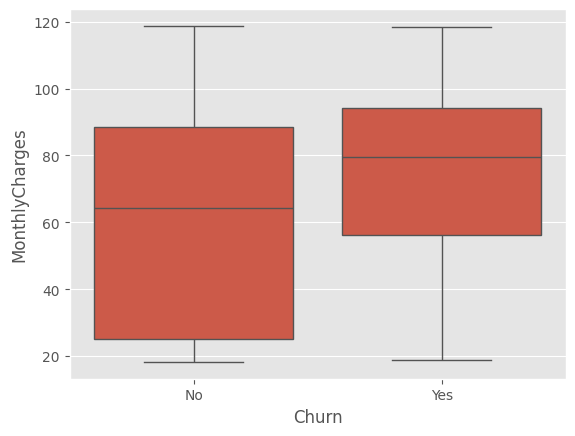

In [29]:
# boxplot for monthly charges feature by churn
sns.boxplot(
    data=df,
    x='Churn',
    y='MonthlyCharges'
)
plt.show()

In [30]:
charges_churned = df[df['Churn'] == 'Yes']['MonthlyCharges']

print(charges_churned.describe())

count    1869.000000
mean       74.441332
std        24.666053
min        18.850000
25%        56.150000
50%        79.650000
75%        94.200000
max       118.350000
Name: MonthlyCharges, dtype: float64


In [31]:
monthlycharges_churn_yes = df[df['Churn'] == 'Yes']['MonthlyCharges']
monthlycharges_churn_no = df[df['Churn'] == 'No']['MonthlyCharges']

stat, p_value = mannwhitneyu(monthlycharges_churn_yes, monthlycharges_churn_no, alternative='two-sided')

print(f'Mann-Whitney U statistic: {stat:.2f}')
print(f'p-value: {p_value:.10f}')


if p_value < 0.5 :
    print('The relationship is significant (H0 is rejected)')
else:
    print("The relationship isn't significant.")

print(f"\nMedian tenure - Churned: {monthlycharges_churn_yes.median()}")
print(f"Median tenure - Not Churned: {monthlycharges_churn_no.median()}")

Mann-Whitney U statistic: 6003125.50
p-value: 0.0000000000
The relationship is significant (H0 is rejected)

Median tenure - Churned: 79.65
Median tenure - Not Churned: 64.42500000000001


### Business Insight

- Customers who churn have higher monthly charges (median around $79.65) compared to customers who stay (median around $64.43).
- The higher monthly charge distribution for churned customers suggests that price sensitivity and higher bills are major driving factors for churn.

## Correlation Matrix

### Which features are correlated with each other?

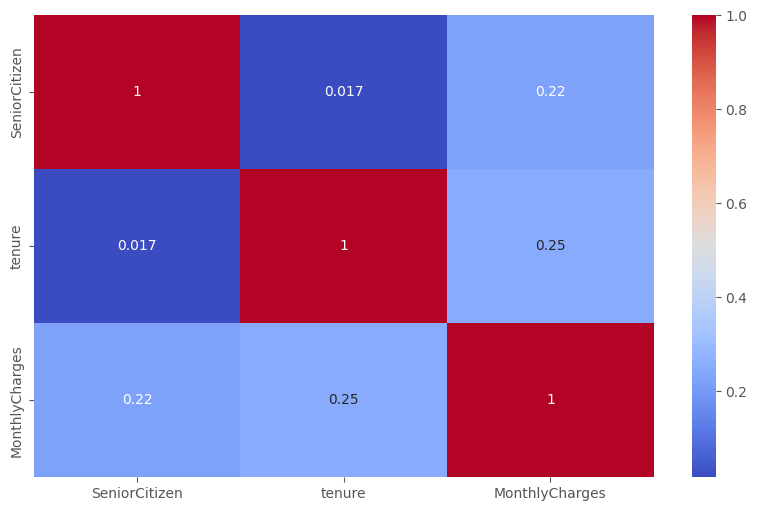

In [32]:
df_numeric = df.select_dtypes(include='number')

plt.figure(figsize=(10, 6))

sns.heatmap(
    df_numeric.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

### Business Insight

- The high correlation between `tenure` and `TotalCharges` suggests potential multicollinearity. If we use linear or logistic models, we should consider dropping or regularizing one of these features.

# Summary 

The plots show that customers with higher monthly chargers is more likely to churn and also the risk of churn customers is much higher in the first few months.

Based on the visual analysis, `tenure`, `MonthlyCharges`, `Contract` type, `InternetService`, and `PaymentMethod` appear to be important predictors of churn.

75% of the people that churned payed more than 56 in a month(`MonthlyCharges`), it suggests that customers who are charged higher amounts are more price sensitive or are not receiving a good deal.